In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import annotate

In [1]:
import sys
print(sys.executable)


/Users/andrewmcclymont/PycharmProjects/PythonProject/.venv/bin/python


In [2]:
df_train  = pd.read_csv('/Users/andrewmcclymont/PycharmProjects/PythonProject/data/Kaggle_House_Price/house-prices-advanced-regression-techniques/train.csv')


In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
from European_RMBS_Model.src.utils.strings import clean_and_snake_case
df_train.columns = [clean_and_snake_case(col) for col in df_train.columns]
df_train

,id,ms_sub_class,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,sale_price
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
df_train.dtypes

id                  int64
ms_sub_class        int64
ms_zoning          object
lot_frontage      float64
lot_area            int64
                   ...   
mo_sold             int64
yr_sold             int64
sale_type          object
sale_condition     object
sale_price          int64
Length: 81, dtype: object

In [6]:
df_train.describe()

,id,ms_sub_class,lot_frontage,lot_area,overall_qual,overall_cond,year_built,year_remod_add,mas_vnr_area,bsmt_fin_sf1,...,wood_deck_sf,open_porch_sf,enclosed_porch,3_ssn_porch,screen_porch,pool_area,misc_val,mo_sold,yr_sold,sale_price
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Making some null data analysis
- As its not a time series I dont need to plot them over time to see if missing data is occuring this was

In [7]:
#Need to first get a summary of the data
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1460 non-null   int64  
 1   ms_sub_class     1460 non-null   int64  
 2   ms_zoning        1460 non-null   object 
 3   lot_frontage     1201 non-null   float64
 4   lot_area         1460 non-null   int64  
 5   street           1460 non-null   object 
 6   alley            91 non-null     object 
 7   lot_shape        1460 non-null   object 
 8   land_contour     1460 non-null   object 
 9   utilities        1460 non-null   object 
 10  lot_config       1460 non-null   object 
 11  land_slope       1460 non-null   object 
 12  neighborhood     1460 non-null   object 
 13  condition1       1460 non-null   object 
 14  condition2       1460 non-null   object 
 15  bldg_type        1460 non-null   object 
 16  house_style      1460 non-null   object 
 17  overall_qual  

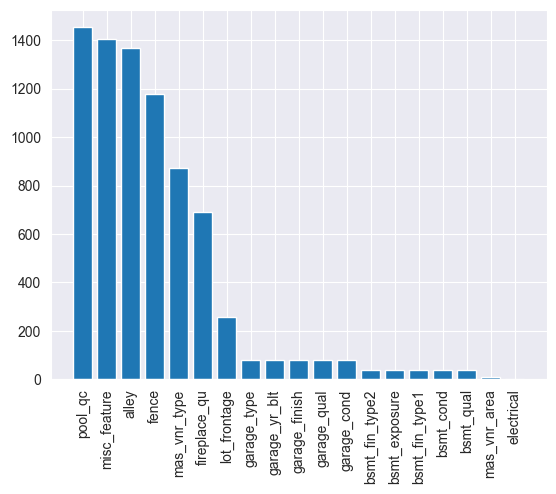

             Field  NullCount
72         pool_qc       1453
74    misc_feature       1406
6            alley       1369
73           fence       1179
25    mas_vnr_type        872
57    fireplace_qu        690
3     lot_frontage        259
58     garage_type         81
59   garage_yr_blt         81
60   garage_finish         81
63     garage_qual         81
64     garage_cond         81
35  bsmt_fin_type2         38
32   bsmt_exposure         38
33  bsmt_fin_type1         37
31       bsmt_cond         37
30       bsmt_qual         37
26    mas_vnr_area          8
42      electrical          1


In [8]:
df_nulls = df_train.isnull().sum().reset_index()
df_nulls = df_nulls.rename(columns={'index':'Field',0:'NullCount'})

df_nulls_only_null = df_nulls[df_nulls['NullCount']!=0].sort_values('NullCount',ascending=False)

# df_nulls_only_null_type = df_nulls_only_null.merge(df_type,how='left',left_on='Field',right_on='Column')

fig,ax = plt.subplots()
plt.bar(data=df_nulls_only_null,height='NullCount',x='Field')
ax.tick_params(axis='x', rotation=90)
plt.show()

print(df_nulls_only_null.head(20))


In [9]:
#Need to come back here: pool qc is a high linear relationship but many missing , if qc is missing why isnt pool area for the same amount?

Start off with the sales price dist

<Axes: xlabel='sale_price', ylabel='Count'>

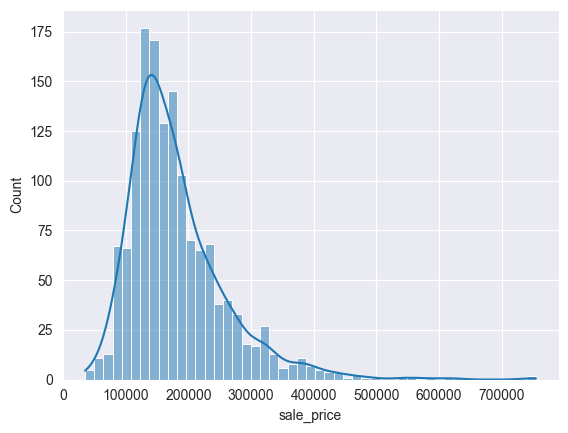

In [10]:
sns.histplot(df_train['sale_price'],kde=True)

#Left skew

Correlation of the data - missing values we can then decide what to do later

In [11]:
corr_table = df_train.corr(numeric_only=True)
corr_table

,id,ms_sub_class,lot_frontage,lot_area,overall_qual,overall_cond,year_built,year_remod_add,mas_vnr_area,bsmt_fin_sf1,...,wood_deck_sf,open_porch_sf,enclosed_porch,3_ssn_porch,screen_porch,pool_area,misc_val,mo_sold,yr_sold,sale_price
id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
ms_sub_class,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
lot_frontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
lot_area,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
overall_qual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
overall_cond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
year_built,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
year_remod_add,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
mas_vnr_area,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
bsmt_fin_sf1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


<Axes: >

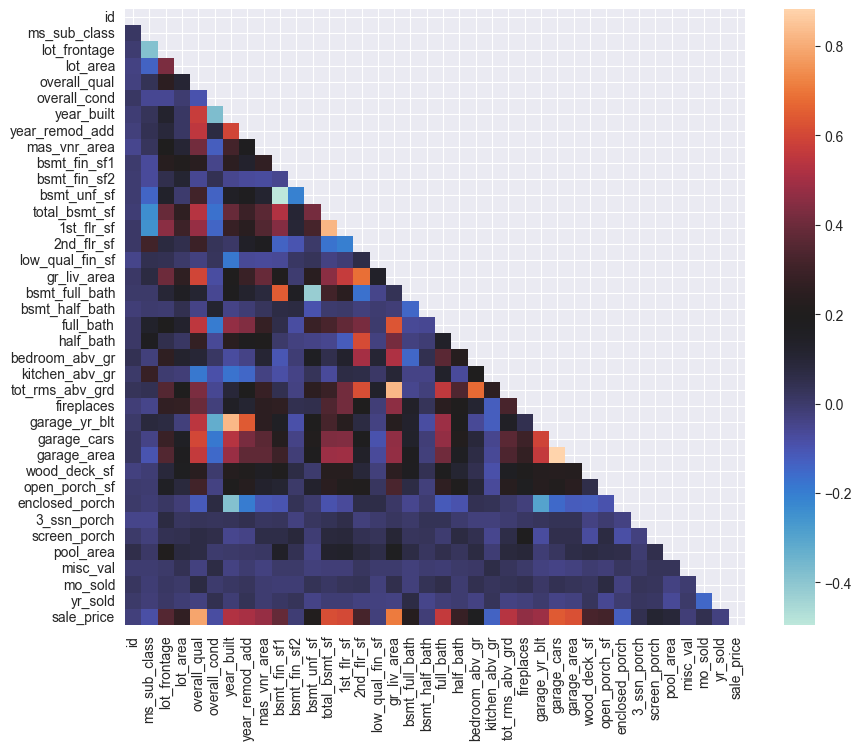

In [12]:
# sns.heatmap(corr_table, annot=False, vmin=-1) #Hard to read

#Use a mask to make the uper true, the np.triu is setting all the above dif to 1, then set mask = mask in the plt and it ignores the top 1 part
mask = np.triu(np.ones_like(corr_table, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr_table, mask=mask,
            cmap='icefire')


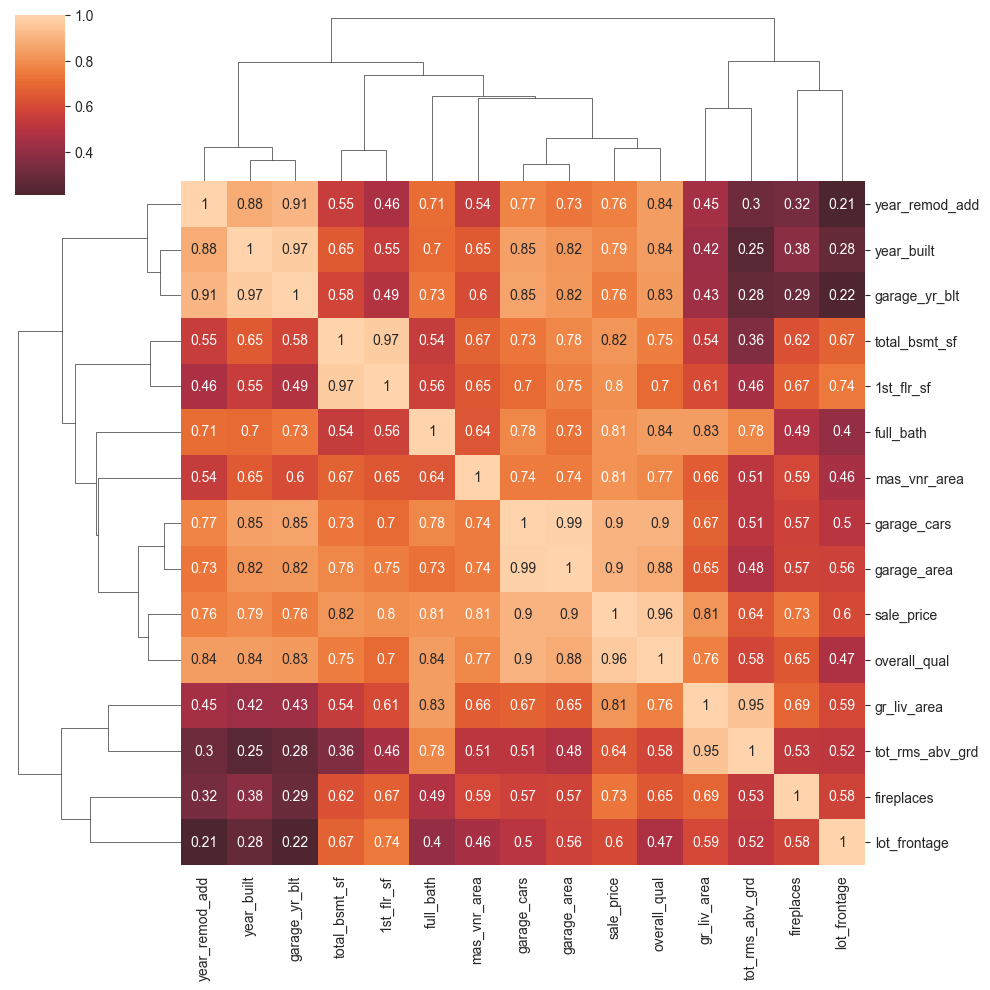

In [13]:
cluster_corr = corr_table.corr().abs().sum().sort_values(ascending=False).head(15).index
sns.clustermap(corr_table[cluster_corr].corr(), cmap="icefire", center=0, annot = True)

# A dendrogram is a hierarchical tree that shows how items cluster together.
# Each leaf (bottom node) = one variable or observation.
# Branches = how similar two leaves (or clusters of leaves) are
# Height of the branch = distance or dissimilarity between clusters.
# Short branches → very similar
# Tall branches → less similar

In [14]:
# cg = sns.clustermap(corr_table[cluster_corr].corr(), cmap="icefire", center=0, annot = True)
# # Get reordered indices
# reordered_indices = cg.dendrogram_row.reordered_ind
#
# # Map indices to column names
# ordered_columns = [cluster_corr[i] for i in reordered_indices]
# print(ordered_columns)

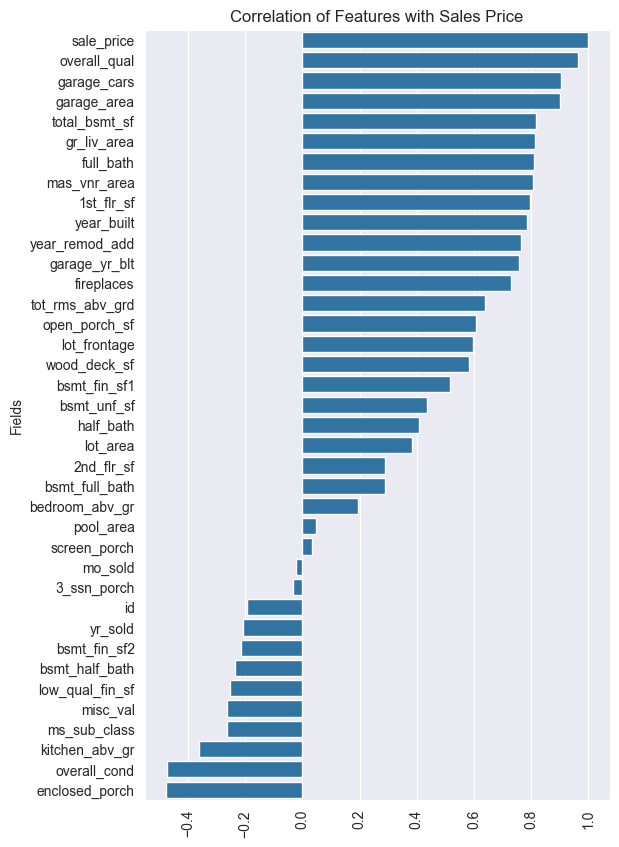

In [15]:
corr_target = corr_table.corr()['sale_price'].sort_values(ascending=False)

plt.figure(figsize=(6,10))
sns.barplot(y=corr_target.index, x=corr_target.values, orient='h')
plt.xticks(rotation=90)
plt.ylabel("Fields")
plt.title('Correlation of Features with Sales Price')
plt.show()


So I have some values that have a linear relationship with sales price, lets now see if these have high % nulls. After I will pair plot, and then look at the realitionshop logic and similatirty

In [16]:
non_null = df_train.count().rename_axis('Field').reset_index(name='NonNullCount')
print(non_null[non_null['Field']=='pool_qc'])


df_nulls_pct = df_nulls.merge(non_null,on='Field',how='left')
df_nulls_pct['TotalCount'] = df_nulls_pct['NullCount'] + df_nulls_pct['NonNullCount']
df_nulls_pct['NullPCT'] = df_nulls_pct['NullCount']/df_nulls_pct['TotalCount']

df_nulls_pct
# print(type(df_nulls_pct))

      Field  NonNullCount
72  pool_qc             7


,Field,NullCount,NonNullCount,TotalCount,NullPCT
0,id,0,1460,1460,0.000000
1,ms_sub_class,0,1460,1460,0.000000
2,ms_zoning,0,1460,1460,0.000000
3,lot_frontage,259,1201,1460,0.177397
4,lot_area,0,1460,1460,0.000000
...,...,...,...,...,...
76,mo_sold,0,1460,1460,0.000000
77,yr_sold,0,1460,1460,0.000000
78,sale_type,0,1460,1460,0.000000
79,sale_condition,0,1460,1460,0.000000


In [17]:
corr_target

sale_price         1.000000
overall_qual       0.962500
garage_cars        0.903554
garage_area        0.900257
total_bsmt_sf      0.817396
gr_liv_area        0.814702
full_bath          0.811329
mas_vnr_area       0.807608
1st_flr_sf         0.797333
year_built         0.785608
year_remod_add     0.762841
garage_yr_blt      0.756271
fireplaces         0.731032
tot_rms_abv_grd    0.638194
open_porch_sf      0.607920
lot_frontage       0.596063
wood_deck_sf       0.581711
bsmt_fin_sf1       0.515448
bsmt_unf_sf        0.436888
half_bath          0.406281
lot_area           0.384865
2nd_flr_sf         0.288677
bsmt_full_bath     0.288590
bedroom_abv_gr     0.193856
pool_area          0.046162
screen_porch       0.034179
mo_sold           -0.022081
3_ssn_porch       -0.032712
id                -0.192466
yr_sold           -0.207811
bsmt_fin_sf2      -0.215899
bsmt_half_bath    -0.234746
low_qual_fin_sf   -0.252426
misc_val          -0.262012
ms_sub_class      -0.263538
kitchen_abv_gr    -0

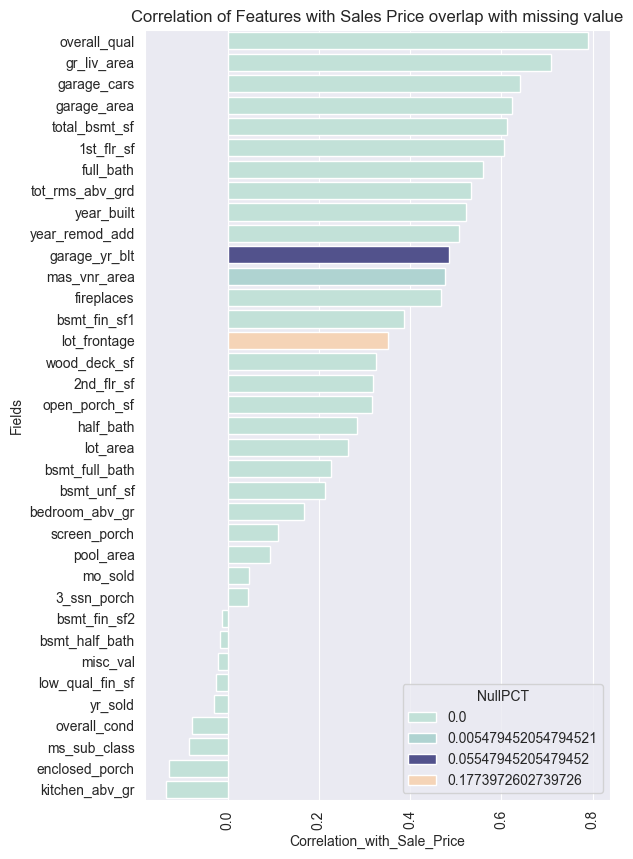

In [18]:
corr_target = corr_table['sale_price'].sort_values(ascending=False)
corr_target.drop(['sale_price','id'],inplace=True)
corr_target_df = corr_target.to_frame(name='Correlation_with_Sale_Price').reset_index().rename(columns={'index': 'Field'})

corr_target_with_null = corr_target_df.merge(df_nulls_pct[['Field', 'NullPCT']], how='left', on='Field')
# print(corr_target_with_null[corr_target_with_null['overall_qual']]) #<- cat variable

plt.figure(figsize=(6,10))
sns.barplot(data = corr_target_with_null, x='Correlation_with_Sale_Price', y='Field', hue = 'NullPCT', orient='h', palette="icefire")
plt.xticks(rotation=90)
plt.ylabel("Fields")
plt.title('Correlation of Features with Sales Price overlap with missing value')
plt.show()




So we can deduce that the numeric values the top 10 linear corr have no missing values and can be used, now to pairplot them, and then look at the cat fields for sales.

In [19]:
#I want to take the 10 linear values, and then do some analysis on the sale, ideally look at cross the cat fields

corr_target_df_top10 = corr_target_df.iloc[0:11,0]
corr_target_df_top10 = corr_target_df_top10.to_list()
corr_target_df_top10

filter_list = corr_target_df_top10 + ['sale_price']

top10_num_linear = df_train[filter_list]

cat_num_metrics = ['overall_qual']
top10_num_linear

,overall_qual,gr_liv_area,garage_cars,garage_area,total_bsmt_sf,1st_flr_sf,full_bath,tot_rms_abv_grd,year_built,year_remod_add,garage_yr_blt,sale_price
0,7,1710,2,548,856,856,2,8,2003,2003,2003.0,208500
1,6,1262,2,460,1262,1262,2,6,1976,1976,1976.0,181500
2,7,1786,2,608,920,920,2,6,2001,2002,2001.0,223500
3,7,1717,3,642,756,961,1,7,1915,1970,1998.0,140000
4,8,2198,3,836,1145,1145,2,9,2000,2000,2000.0,250000
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,2,7,1999,2000,1999.0,175000
1456,6,2073,2,500,1542,2073,2,7,1978,1988,1978.0,210000
1457,7,2340,1,252,1152,1188,2,9,1941,2006,1941.0,266500
1458,5,1078,1,240,1078,1078,1,5,1950,1996,1950.0,142125


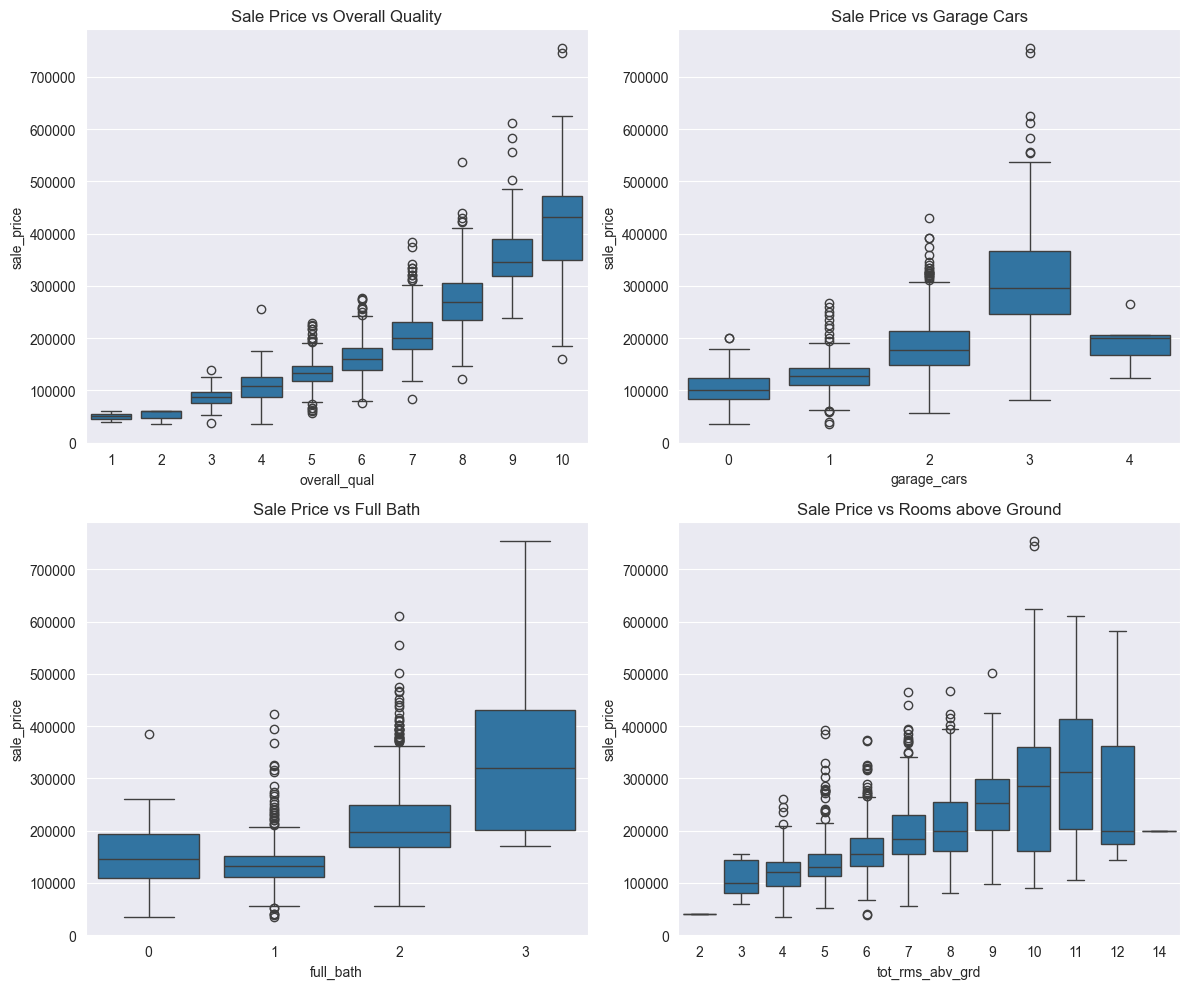

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid

sns.boxplot(data=top10_num_linear, x='overall_qual', y='sale_price', ax=axes[0,0])
axes[0,0].set_title('Sale Price vs Overall Quality')

sns.boxplot(data=top10_num_linear, x='garage_cars', y='sale_price', ax=axes[0,1])
axes[0,1].set_title('Sale Price vs Garage Cars')

sns.boxplot(data=top10_num_linear, x='full_bath', y='sale_price', ax=axes[1,0])
axes[1,0].set_title('Sale Price vs Full Bath')

sns.boxplot(data=top10_num_linear, x='tot_rms_abv_grd', y='sale_price', ax=axes[1,1])
axes[1,1].set_title('Sale Price vs Rooms above Ground')

plt.tight_layout()
plt.show()

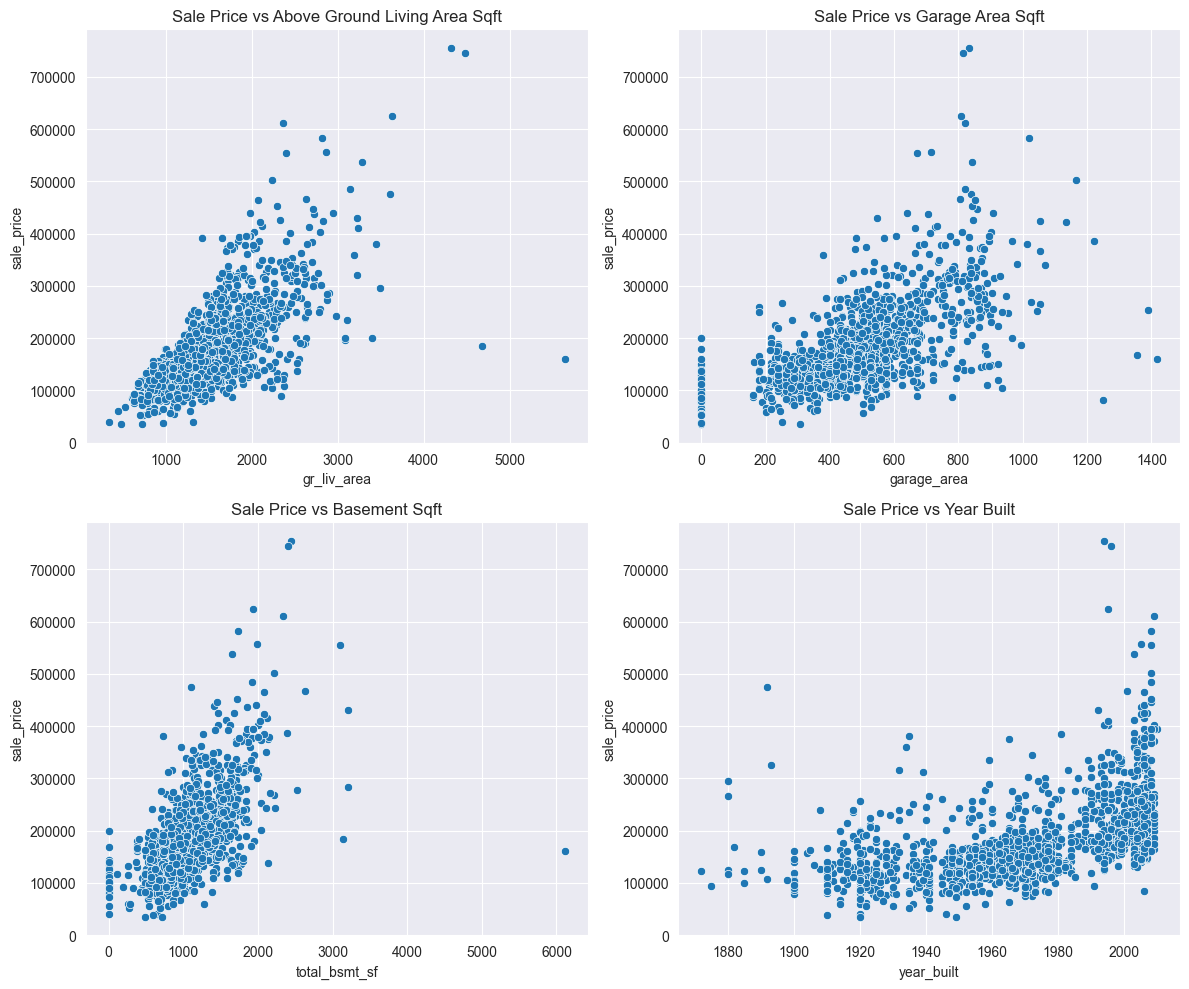

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid

sns.scatterplot(data=top10_num_linear, x='gr_liv_area', y='sale_price', ax=axes[0,0])
axes[0,0].set_title('Sale Price vs Above Ground Living Area Sqft')

sns.scatterplot(data=top10_num_linear, x='garage_area', y='sale_price', ax=axes[0,1])
axes[0,1].set_title('Sale Price vs Garage Area Sqft')

sns.scatterplot(data=top10_num_linear, x='total_bsmt_sf', y='sale_price', ax=axes[1,0])
axes[1,0].set_title('Sale Price vs Basement Sqft')

sns.scatterplot(data=top10_num_linear, x='year_built', y='sale_price', ax=axes[1,1])
axes[1,1].set_title('Sale Price vs Year Built')

plt.tight_layout()
plt.show()

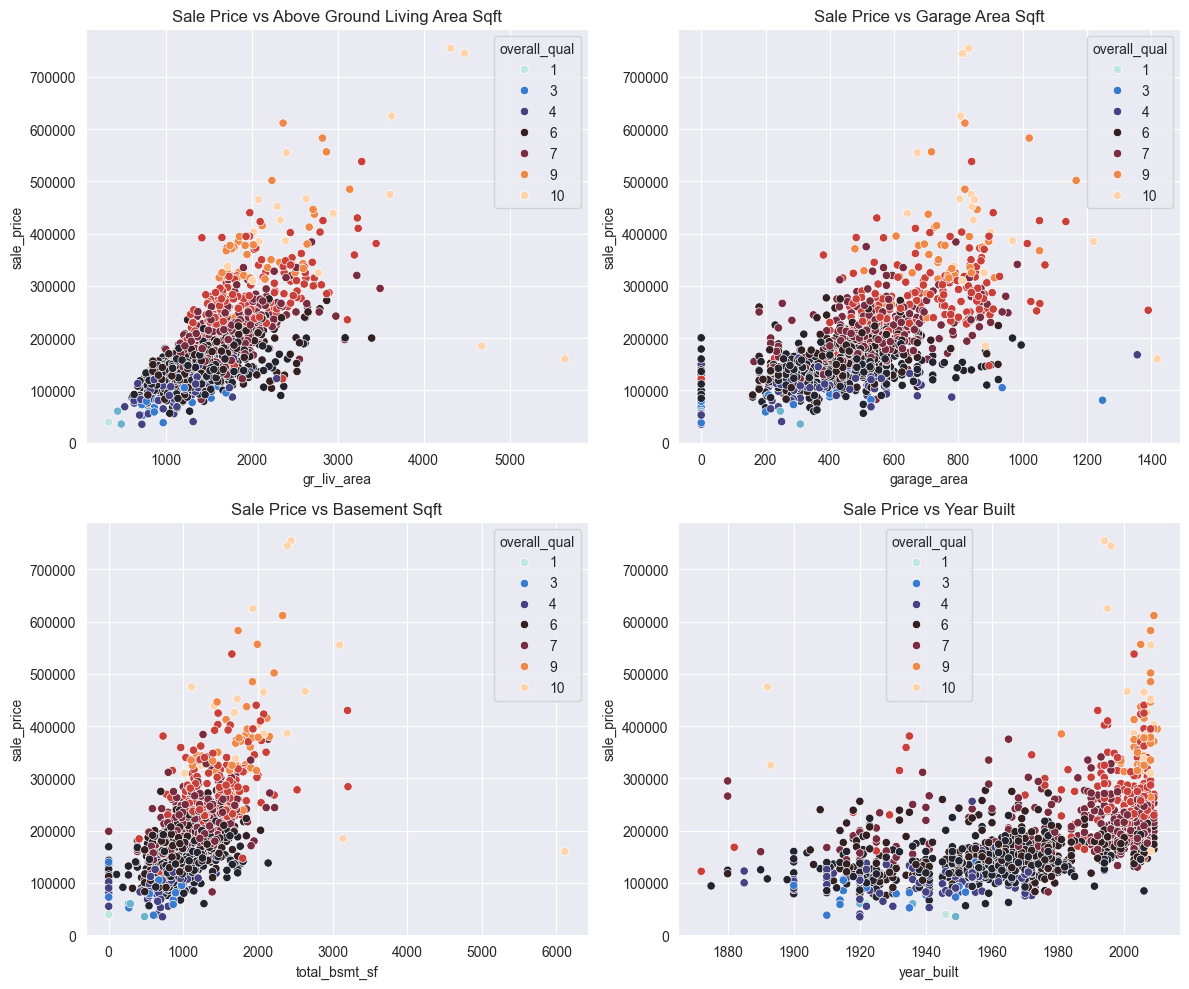

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid

sns.scatterplot(data=top10_num_linear, x='gr_liv_area', y='sale_price', hue='overall_qual' , palette="icefire" ,ax=axes[0,0])
axes[0,0].set_title('Sale Price vs Above Ground Living Area Sqft')

sns.scatterplot(data=top10_num_linear, x='garage_area', y='sale_price',hue='overall_qual' , palette="icefire" ,ax=axes[0,1])
axes[0,1].set_title('Sale Price vs Garage Area Sqft')

sns.scatterplot(data=top10_num_linear, x='total_bsmt_sf', y='sale_price',hue='overall_qual' , palette="icefire" , ax=axes[1,0])
axes[1,0].set_title('Sale Price vs Basement Sqft')

sns.scatterplot(data=top10_num_linear, x='year_built', y='sale_price',hue='overall_qual' , palette="icefire" , ax=axes[1,1])
axes[1,1].set_title('Sale Price vs Year Built')

plt.tight_layout()
plt.show()

Can do some FE

In [23]:
# def feature_engineering(df):
#
#     # Basic engineered features
#     df['TotalBath'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
#     df['HasPool'] = (df['PoolArea'] > 0).astype(int)
#     df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
#     df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
#     df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
#     df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
#
#     df['BuildingAge'] = df['YrSold'] - df['YearBuilt']
#     df['BuildingAge'] = df['BuildingAge'].clip(lower=0)
#
#     df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
#     df['IsNew'] = (df['BuildingAge'] <= 2).astype(int)
#
#     df["TotalSF"] = df["1stFlrSF"] + df["2ndFlrSF"] + df["TotalBsmtSF"] + df["GrLivArea"]
#     df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
#
#     df['TotalPorch'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
#     df['OverallQual_TotalSF'] = df['OverallQual'] * df['TotalSF']
#     df['OverallQual_GrLivArea'] = df['OverallQual'] * df['GrLivArea']
#
#     return df

Do the analysis of pair features so we arnt caputring the same thing each time

In [24]:
# Select top 15 features
cluster_corr = corr_table.corr().abs().sum().sort_values(ascending=False).head(15).index
corr_matrix = corr_table[cluster_corr].corr().abs()

# Mask the upper triangle (so we don't duplicate pairs)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_pairs = corr_matrix.where(mask)

# Threshold for "too similar"
threshold = 0.8
high_corr = corr_pairs.stack().reset_index()
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'] > threshold].sort_values(by='Correlation', ascending=False)
print(high_corr)

        Feature_1        Feature_2  Correlation
27    garage_cars      garage_area     0.987115
79     year_built    garage_yr_blt     0.974033
53  total_bsmt_sf       1st_flr_sf     0.966775
0      sale_price     overall_qual     0.962500
75    gr_liv_area  tot_rms_abv_grd     0.945444
95  garage_yr_blt   year_remod_add     0.905028
1      sale_price      garage_cars     0.903554
14   overall_qual      garage_cars     0.903027
2      sale_price      garage_area     0.900257
80     year_built   year_remod_add     0.882628
15   overall_qual      garage_area     0.879904
34    garage_cars    garage_yr_blt     0.853233
31    garage_cars       year_built     0.845694
19   overall_qual       year_built     0.840867
23   overall_qual   year_remod_add     0.837096
17   overall_qual        full_bath     0.836586
60      full_bath      gr_liv_area     0.834585
22   overall_qual    garage_yr_blt     0.830695
45    garage_area    garage_yr_blt     0.819488
3      sale_price    total_bsmt_sf     0

In [25]:
filter_list

['overall_qual',
 'gr_liv_area',
 'garage_cars',
 'garage_area',
 'total_bsmt_sf',
 '1st_flr_sf',
 'full_bath',
 'tot_rms_abv_grd',
 'year_built',
 'year_remod_add',
 'garage_yr_blt',
 'sale_price']

Simple Regression
- would first have done outlier analysis, some feature engineering etc
- would also want to see some more columns combined influence

In [26]:
df_train.columns

Index(['id', 'ms_sub_class', 'ms_zoning', 'lot_frontage', 'lot_area', 'street',
       'alley', 'lot_shape', 'land_contour', 'utilities', 'lot_config',
       'land_slope', 'neighborhood', 'condition1', 'condition2', 'bldg_type',
       'house_style', 'overall_qual', 'overall_cond', 'year_built',
       'year_remod_add', 'roof_style', 'roof_matl', 'exterior1st',
       'exterior2nd', 'mas_vnr_type', 'mas_vnr_area', 'exter_qual',
       'exter_cond', 'foundation', 'bsmt_qual', 'bsmt_cond', 'bsmt_exposure',
       'bsmt_fin_type1', 'bsmt_fin_sf1', 'bsmt_fin_type2', 'bsmt_fin_sf2',
       'bsmt_unf_sf', 'total_bsmt_sf', 'heating', 'heating_qc', 'central_air',
       'electrical', '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf',
       'gr_liv_area', 'bsmt_full_bath', 'bsmt_half_bath', 'full_bath',
       'half_bath', 'bedroom_abv_gr', 'kitchen_abv_gr', 'kitchen_qual',
       'tot_rms_abv_grd', 'functional', 'fireplaces', 'fireplace_qu',
       'garage_type', 'garage_yr_blt', 'garage_finish'

In [27]:
import statsmodels.formula.api as smf

model = smf.ols('sale_price ~ overall_qual + year_built + C(ms_zoning)', data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             sale_price   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     450.2
Date:                Sat, 20 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:46:37   Log-Likelihood:                -17777.
No. Observations:                1460   AIC:                         3.557e+04
Df Residuals:                    1453   BIC:                         3.561e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -4.116e+05   1.03

In [28]:
df_test  = pd.read_csv('/Users/andrewmcclymont/PycharmProjects/PythonProject/data/Kaggle_House_Price/house-prices-advanced-regression-techniques/test.csv')
from European_RMBS_Model.src.utils.strings import clean_and_snake_case
df_test.columns = [clean_and_snake_case(col) for col in df_test.columns]
df_test

,id,ms_sub_class,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,...,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [29]:
df.columns()

NameError: name 'df' is not defined

In [77]:
test = df_test[df_test['id']==1461]
test['id','sales_price']

KeyError: ('id', 'sales_price')

In [73]:
y_pred_test = model.predict(df_test)
y_pred_test_df = y_pred_test.to_frame()
y_pred_test_df = y_pred_test_df.rename(columns={0:'sale_price_predicted'})
y_pred_test_df

,sale_price_predicted
0,123507.560478
1,180024.781381
2,144112.910810
3,186691.949893
4,270516.594356
...,...
1454,69101.333632
1455,69101.333632
1456,137945.779937
1457,143279.514746


In [68]:
output = df_test.merge(y_pred_test_df,how='left',right_index=True, left_on='id')
# output['id','sale_price','sale_price_predicted']

output

,id,ms_sub_class,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,sale_price_predicted
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,NaN
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,NaN
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,NaN
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,NaN
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
